# import database
basic info: stock_daily consists of 4 stocks, 300476 corresponds to Synthesis Electronic Technology Co., Ltd., a Chinese technology company listed on the is listed on the ChiNext board of Shenzhen Stock Exchange (SZSE). (I only added this info coz its related to limit-up)
They specialize in identity authentication terminals and artificial intelligence solutions for public and enterprise security sectors

In [ ]:
import mysql.connector
import numpy as np
import pandas as pd

import qlib
from qlib.constant import REG_CN
from qlib.contrib.data.handler import Alpha158

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

import lightgbm as lgb

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

In [ ]:
# Connect to your MySQL database
import os
from dotenv import load_dotenv

load_dotenv()  # reads the .env file into environment variables

conn = mysql.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

# Load a table into a DataFrame
df = pd.read_sql("SELECT date, stock_code, open, high, low, close, volume " \
"FROM stock_daily WHERE stock_code = 300476", conn)

conn.close()

df.head()

/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_15526/427148155.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT date, stock_code, open, high, low, close, volume FROM stock_daily WHERE stock_code = 300476", conn)


,date,stock_code,open,high,low,close,volume
0,2023-01-31,300476,14.16,14.26,14.12,14.21,57594.0
1,2023-02-01,300476,14.23,14.57,14.21,14.52,107797.0
2,2023-02-02,300476,14.52,14.72,14.45,14.50,115191.0
3,2023-02-03,300476,14.46,14.78,14.44,14.77,156534.0
4,2023-02-06,300476,14.65,14.88,14.60,14.86,112518.0


# data inspection

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 813 entries, 0 to 812
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        813 non-null    object 
 1   stock_code  813 non-null    str    
 2   open        813 non-null    float64
 3   high        813 non-null    float64
 4   low         813 non-null    float64
 5   close       813 non-null    float64
 6   volume      813 non-null    float64
dtypes: float64(5), object(1), str(1)
memory usage: 44.6+ KB


In [ ]:
# take a look at the numeric values
######## actly this should be done after the null and date check

print(df.describe())
# the stock fluctuates a lot

print('-' * 70)

# check if there's negative value
for col in ['open', 'high', 'low', 'close', 'volume']:
    if (df[col] < 0).any():
        print(f"Negative values found in column: {col}")
    else:
        print(f"No negative values in column: {col}")


             open        high         low       close        volume
count  813.000000  813.000000  813.000000  813.000000  8.130000e+02
mean   102.313419  105.823555   99.707528  102.838007  4.239246e+05
std    112.595732  116.430707  109.598277  113.085403  2.277364e+05
min     14.160000   14.260000   13.860000   14.210000  5.759400e+04
25%     22.250000   22.860000   21.810000   22.360000  2.791710e+05
50%     39.660000   40.870000   37.880000   39.470000  3.743260e+05
75%    187.620000  194.640000  184.000000  191.350000  5.120440e+05
max    390.000000  402.600000  376.890000  392.950000  1.922923e+06
----------------------------------------------------------------------
No negative values in column: open
No negative values in column: high
No negative values in column: low
No negative values in column: close
No negative values in column: volume


In [ ]:
# extreme value check (limit-up for A-share)

####### the limit-up is 20% for this stock (A股涨停标准)
def get_limitup(table, r): # OHLCV table, ratio for limit
    d_limit = {'limit_up': [], 'limit_down': []}
    for i in range(len(table) - 1):
        yest_close = table.iloc[i]['close']
        if table.iloc[i + 1]['high'] >= yest_close * (1 + r):
            print('limit-up:')
            print(pd.DataFrame(table.iloc[i: (i + 2)]))
            d_limit['limit_up'] .append(table.iloc[i+1]['date'])
        if table.iloc[i + 1]['low'] <= yest_close * (1 - r):
            print('limit-down:')
            print(pd.DataFrame(table.iloc[i: (i + 2)]))
            d_limit['limit_down'].append(table.iloc[i+1]['date'])
    return d_limit # return limit-up and down dates
   
get_limitup(df, 0.2)

limit-up:
           date stock_code   open   high    low  close    volume
407  2024-09-30     300476  35.00  39.76  34.10  39.70  690147.0
408  2024-10-08     300476  47.19  47.64  41.24  47.64  824131.0
limit-up:
           date stock_code   open   high     low  close    volume
633  2025-09-04     300476  285.0  288.0  243.38  246.5  745408.0
634  2025-09-05     300476  256.0  295.8  249.03  295.8  872474.0


{'limit_up': [datetime.date(2024, 10, 8), datetime.date(2025, 9, 5)],
 'limit_down': []}

In [ ]:
df.isnull().sum()
# no null values
####### this should be infront

date          0
stock_code    0
open          0
high          0
low           0
close         0
volume        0
dtype: int64

In [ ]:
df.shape
####### this should be infront too

(813, 7)

In [ ]:
# a special focus on date: 
# to prevent data leakage and for model training consistency this is neccessary!!

print('start_date:', min(df['date']))
print('end_date:', max(df['date']))
# two and a half year time span

# check if the data is sorted by date
is_sorted = df['date'].is_monotonic_increasing
print('Is the data sorted by date?', is_sorted)

######## alternatively let's use a basic loop
######## well this AI is too clever that it wrote it for me so I cannot practice :(

# check if the date has duplicates
has_duplicates = df['date'].duplicated().any()
print('Does the date column have duplicates?', has_duplicates)

######## this can also use a loop

# check if there are missing TRADE dates
######## i dont have a dataset for marked trade dates to do the check
######## the basic idea tho is to match the 2 tables in a loop and print out the missing dates

start_date: 2023-01-31
end_date: 2026-06-08
Is the data sorted by date? True
Does the date column have duplicates? False


# label design
- single stock:
1 day return --> 5 day return --> category label (commonly seen 3 kinds)
(by return we mean FUTURE return)
- multiple stock: 
reminder to choose the same stock id

In [ ]:
df["label_1d"] = df["close"].shift(-2) / df["close"].shift(-1) - 1
df["label_5d"] = df["close"].shift(-6)/ df["close"].shift(-1) - 1
print(df.head())
print(df.tail())
######## we alreeady know df['close'] for tdy so it cannot be included in the label
######## since it is unrealistic to trade right on spot

# categorical
######## we leave this blank for now

         date stock_code   open   high    low  close    volume  label_1d  \
0  2023-01-31     300476  14.16  14.26  14.12  14.21   57594.0 -0.001377   
1  2023-02-01     300476  14.23  14.57  14.21  14.52  107797.0  0.018621   
2  2023-02-02     300476  14.52  14.72  14.45  14.50  115191.0  0.006093   
3  2023-02-03     300476  14.46  14.78  14.44  14.77  156534.0  0.011440   
4  2023-02-06     300476  14.65  14.88  14.60  14.86  112518.0 -0.005988   

   label_5d  
0  0.028926  
1  0.177241  
2  0.237644  
3  0.296770  
4  0.200266  
           date stock_code    open    high     low   close    volume  \
808  2026-06-02     300476  343.00  356.31  334.16  349.08  420825.0   
809  2026-06-03     300476  349.08  369.15  345.01  353.44  535732.0   
810  2026-06-04     300476  346.00  373.30  344.70  366.72  513439.0   
811  2026-06-05     300476  359.84  360.00  336.50  338.90  553281.0   
812  2026-06-08     300476  307.00  325.47  306.56  324.96  392793.0   

     label_1d  label_5d  


# feature design

mannual feature design
- the difference between feature and label design is that feature CANNOT include future data and label pratically can ONLY include future data

In [ ]:
# write some alphas by myself
####### later i'll delete them and just use Alpha158

# basic percentage change
df["ret_1d"] = df["close"].pct_change(1)
df["ret_5d"] = df["close"].pct_change(5)
df["ret_10d"] = df["close"].pct_change(10)

# fluctuate
df["vol_5d"] = df["ret_1d"].rolling(5).std().reset_index(level=0, drop=True)
df["vol_10d"] = df["ret_1d"].rolling(10).std().reset_index(level=0, drop=True)

# rolling average
ma5 = df["close"].rolling(5).mean().reset_index(level=0, drop=True)
ma20 = df["close"].rolling(20).mean().reset_index(level=0, drop=True)
df["close_ma5_ratio"] = df["close"] / ma5 - 1
df["close_ma20_ratio"] = df["close"] / ma20 - 1

# volume
df["volume_chg_1d"] = df["volume"].pct_change(1)
df["volume_ma5_ratio"] = df["volume"] / df["volume"].rolling(5).mean().reset_index(level=0, drop=True) - 1

# k value
df["intraday_ret"] = df["close"] / df["open"] - 1
df["high_low_ratio"] = df["high"] / df["low"] - 1
df["close_to_high"] = df["close"] / df["high"] - 1
df["close_to_low"] = df["close"] / df["low"] - 1

print(df.head())
print(df.tail())
####### i just want to take a look

insert Alpha158

In [ ]:
# data prep for inputting the file into Alpha158 (qlib)

# save the dataframe into a csv file
df_qlib = (df.iloc[:, 0:7]).drop('stock_code', axis=1)
df_qlib['factor'] = 1.0

print(df_qlib.head())

output_dir = "test_run"
os.makedirs(output_dir, exist_ok=True)
out_path = os.path.join(output_dir, f"tech_stock.csv")
df_qlib.to_csv(out_path, index=False)

# turn the csv file into qlib binary format

In [ ]:
# get the dataset with alpha158 implemented
qlib.init(provider_uri="qlib_data/", region=REG_CN)

handler = Alpha158(
    # the full time length including train, valid and test
    start_time="2023-01-31",
    end_time="2026-06-08",
    # the normalization scope
    ######## this is almost always the same as the training window
    ######## otherwise (i.e. larger than train window) it might result in data leakage 
    fit_start_time="2023-01-31",
    fit_end_time="2025-05-30",
    
    # irrelevant when looking at single stock data
    # however the para could instead pass a specific list of tickers or a predefined pool name
    instruments=['tech_stock',],
)

data = handler.fetch()
print(data.shape)

[20763:MainThread](2026-07-06 16:16:33,319) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[20763:MainThread](2026-07-06 16:16:34,582) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[20763:MainThread](2026-07-06 16:16:34,583) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': PosixPath('/Users/hanxi/.qlib/qlib_data/my_custom_data')}
[20763:MainThread](2026-07-06 16:16:34,777) INFO - qlib.timer - [log.py:127] - Time cost: 0.192s | Loading data Done
[20763:MainThread](2026-07-06 16:16:34,782) INFO - qlib.timer - [log.py:127] - Time cost: 0.004s | DropnaLabel Done
[20763:MainThread](2026-07-06 16:16:35,093) INFO - qlib.timer - [log.py:127] - Time cost: 0.310s | CSZScoreNorm Done
[20763:MainThread](2026-07-06 16:16:35,093) INFO - qlib.timer - [log.py:127] - Time cost: 0.316s | fit & process data Done
[20763:MainThread](2026-07-06 16:16:35,094) INFO - qlib.timer - [log.py:127] - Time cos

(813, 159)


In [6]:
data.head()

,,KMID,KLEN,KMID2,KUP,KUP2,KLOW,KLOW2,KSFT,KSFT2,OPEN0,...,VSUMN10,VSUMN20,VSUMN30,VSUMN60,VSUMD5,VSUMD10,VSUMD20,VSUMD30,VSUMD60,LABEL0
datetime,instrument,,,,,,,,,,,,,,,,,,,,,
2023-01-31,TECH_STOCK,0.003531,0.009887,0.357143,0.003531,0.357143,0.002825,0.285713,0.002825,0.285713,0.996481,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001377
2023-02-01,TECH_STOCK,0.020380,0.025299,0.805559,0.003514,0.138887,0.001405,0.055554,0.018271,0.722226,0.980027,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.018621
2023-02-02,TECH_STOCK,-0.001377,0.018595,-0.074076,0.013774,0.740739,0.003444,0.185186,-0.011708,-0.629629,1.001379,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.006093
2023-02-03,TECH_STOCK,0.021438,0.023513,0.911766,0.000692,0.029410,0.001383,0.058825,0.022130,0.941181,0.979011,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.011440
2023-02-06,TECH_STOCK,0.014334,0.019113,0.750001,0.001365,0.071430,0.003413,0.178569,0.016382,0.857139,0.985868,...,0.307899,0.307899,0.307899,0.307899,0.384202,0.384202,0.384202,0.384202,0.384202,-0.005988


# model fitting
Now we have our data prepared there are 3 models i'd like to fit:
- Ridge(linear) --> LightGBM (a complex tree) --> MLP(nural network)

data cleaning for Ridge and MLP
- these models cannot handel NAs
- they have alr been standardized by Aalpha158 so no need to standardize again

In [ ]:
# check NAs in the columns
data.isna().sum().sort_values(ascending=False).head(10)

VWAP0     813
ROC60      60
ROC30      30
ROC20      20
ROC10      10
ROC5        5
LABEL0      2
CORD20      2
CORD10      2
CORD5       2
dtype: int64

In [43]:
# VWAP0 is volumn-weighted average price, which needs intraday tick/ trade data to compute
# which is hard to reconstruct, so usually we approximate daily vwap as:
# df["vwap"] = (df["high"] + df["low"] + df["close"]) / 3
# and then put this column alonside OHLCV then input into the csv file
######### for now let's just drop it
X =  data.iloc[:, 0:158].drop(columns='VWAP0')
y = data.iloc[:, 158] # the label

In [ ]:
# drop all rows with NaN
keep = X.notna().all(axis=1) & y.notna()
X, y = X[keep], y[keep]
print((X.isna().sum() == 0).sum(), y.isna().sum()) # check if we dropped every NA

157 0


split data
- train: ~70%, valid: ~15% and test: ~15%
    - 7/1.5/1.5 is the conventional ML training data split

- for finacial datasets, there are other concerns: 
    - chronological: no random shifting
    - market regime: it cannot only be in a bull/bear market regime (a content consideration)
    - test period is advised to be long: financial data is extemely noisy

- a more rigorous practice: walk-forward or rolling, multiple splits
    - e.g. train: yr1 test: yr2
         train: y1 yr2 test: yr3
         exc.

In [ ]:
train_dates = slice("2023-01-31", "2025-05-30")
valid_dates = slice("2025-06-03", "2025-12-31")
test_dates  = slice("2026-01-05", "2026-06-08")

X_train, y_train = X.loc[train_dates], y.loc[train_dates]
X_valid, y_valid = X.loc[valid_dates], y.loc[valid_dates]
X_test,  y_test  = X.loc[test_dates],  y.loc[test_dates]

print(len(y_train) + len(y_valid) + len(y_test)) # check slicing

751


# Ridge 

In [52]:
best_alpha, best_score = None, np.inf
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train.values.ravel())
    preds = model.predict(X_valid)
    score = mean_squared_error(y_valid, preds)
    if score < best_score:
        best_alpha, best_score = alpha, score

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train, y_train.values.ravel())

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",100.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga

model evaluation
- classification matrices: AUC, ROC and confusion matrix (for discrete outcomes)
- regression matrices:
- Test MSE (Mean Squared Error = mean((actual - predicted)**2))
- Test MAE (Mean Absolute Error = MAE = mean(abs(actual - predicted)))
    - if MSE is much larger/smaller relative to MAE, it signals a few large errors are dragging the average up (since MSE punishes those harder)
- Pearson correlation (mesures linear relation strength)
- Rank IC: Spearman correlation (works on multi stock data, similar to AUC)
(for continuous values)

In [70]:
# evaluation for Ridge
test_preds = final_model.predict(X_test)
pred_series = pd.Series(test_preds, index=X_test.index)

####### since we only have one stock, let's use MSE, MAE and pearson

# MSE
mse = np.mean((pred_series - y_test) ** 2)
# MAE
mae = np.mean(np.abs(pred_series - y_test))
# pearson corr
p_corr = pred_series.corr(y_test)

print('MSE:', mse, 'MAE:', mae, 'corr:', p_corr)
# result: MSE: 0.0014625103 MAE: 0.030359257 corr: 0.09631084704632753
######## the correlation is actually not bad for a stock??

MSE: 0.0014625103 MAE: 0.030359257 corr: 0.09631084704632753


# LightGBM
LightGBM handels NAs naively but since we want to compare it to Ridge let's just use the same train, valid and test data set 

In [ ]:
train_set = lgb.Dataset(X_train, label=y_train)
valid_set = lgb.Dataset(X_valid, label=y_valid, reference=train_set)

params = {
    "objective": "regression",
    "metric": "mse",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "verbose": -1,
}

lgb_model = lgb.train(
    params,
    train_set,
    num_boost_round=500,
    valid_sets=[valid_set],
    callbacks=[lgb.early_stopping(stopping_rounds=20)] # watches validation loss
)

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	valid_0's l2: 0.00284811


In [ ]:
######## get the important features like all tree models
importances = pd.Series(lgb_model.feature_importance(importance_type="gain"),
                         index=X_train.columns)
print(importances.sort_values(ascending=False).head(10))

# let's inspect the 3 most imprtant features for fun
# RESI30: deviation from a 30-day linear trend ≈ (actual_close_today - fitted_line_value_today) / close_today
# IMIN20: timing of the recent low ≈ (how many days ago the lowest price in the past 20 days occurred) / 20
# STD20: rolling volatility = std(close, past 20 days) / close_today

RESI30    0.031201
IMIN20    0.028645
STD20     0.025952
KMID      0.022091
VSTD30    0.021122
MAX10     0.018413
QTLU30    0.018244
QTLD5     0.017360
ROC5      0.014875
VMA60     0.013269
dtype: float64


In [ ]:
# evaluation for LightGMB
test_preds_lgb = lgb_model.predict(X_test, num_iteration = lgb_model.best_iteration)
pred_series_lgb = pd.Series(test_preds_lgb, index=X_test.index)

# MSE
mse_lgb = np.mean((pred_series_lgb - y_test) ** 2)
# MAE
mae_lgb = np.mean(np.abs(pred_series_lgb - y_test))
# pearson corr
p_corr_lgb = pred_series_lgb.corr(y_test)

print('MSE:', mse_lgb, 'MAE:', mae_lgb, 'corr:', p_corr_lgb)
# MSE: 0.0014723650482226746 MAE: 0.0304661139815016 corr: -0.059706803879101135
######## it has a negative correlation, like sort of worse than no signal at all?

MSE: 0.0014723650482226746 MAE: 0.0304661139815016 corr: -0.059706803879101135


In [ ]:
####### the correlation is too bad so we check if the model is overfitted
####### small data sets are easily overfitted
train_preds_lgb = lgb_model.predict(X_train, num_iteration=lgb_model.best_iteration)
train_corr_lgb = pd.Series(train_preds_lgb).corr(pd.Series(y_train.values))
print(f"Train corr: {train_corr_lgb:.4f}") # Train corr: 0.5238, which is quite high

Train corr: 0.5238


# MLP

input data
- no NA allowed
- train and test set: for the sklearn MLP model the valid set is chosen randonly with no        choroniacal order within the train set so it might lead to data leakage, in real practice, we control the valid set by directly monitoring pytorch
- MLP requires standardization (more important than LR: with layers)

In [ ]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),   # small, given your ~750-row dataset
    # layers: avoid overfitting
    activation="relu",
    solver="adam",
    alpha=0.05,                     # L2 regularization: important given small data
    # penalize large weight values, pushing wights to smaller values: also avoid overfitting
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,           # uses internal validation split to stop before overfitting
    # even though it causes data leakage, this is a small data set
    validation_fraction=0.15,   # ratio for the random valid set
    n_iter_no_change=20,
    random_state=42,    #reproducibility
)

mlp_model.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.05
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by atleast ``tol`` for ``n_iter_no_change`` consecutive epochs.Only effective when solver='sgd' or 'adam'.",True
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True.",0.15
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",20
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'


In [ ]:
# evaluation for MLP
test_preds_mlp = mlp_model.predict(X_test)
pred_series_mlp = pd.Series(test_preds_mlp, index=X_test.index)

# MSE
mse_mlp = np.mean((pred_series_mlp - y_test) ** 2)
# MAE
mae_mlp = np.mean(np.abs(pred_series_mlp - y_test))
# pearson corr
p_corr_mlp = pred_series_mlp.corr(y_test)

print('MSE:', mse_mlp, 'MAE:', mae_mlp, 'corr:', p_corr_mlp)
# MSE: 0.0020822224 MAE: 0.035063542 corr: 0.03951407840335921 (alpha = 0.01)
######## then i tried a bit of tuning
# MSE: 0.001752092 MAE: 0.032651495 corr: 0.09312273069114023 (alpha = 0.05)

MSE: 0.001752092 MAE: 0.032651495 corr: 0.09312273069114023


In [ ]:
# check overfitting for MLP
# eventhough the 
train_preds_mlp = mlp_model.predict(X_train)
train_corr_mlp = pd.Series(train_preds_mlp).corr(pd.Series(y_train.values))
print(f"Train corr: {train_corr_mlp:.4f}") # Train corr: 0.5168, similar to LightGBM

Train corr: 0.5168


# model visualization

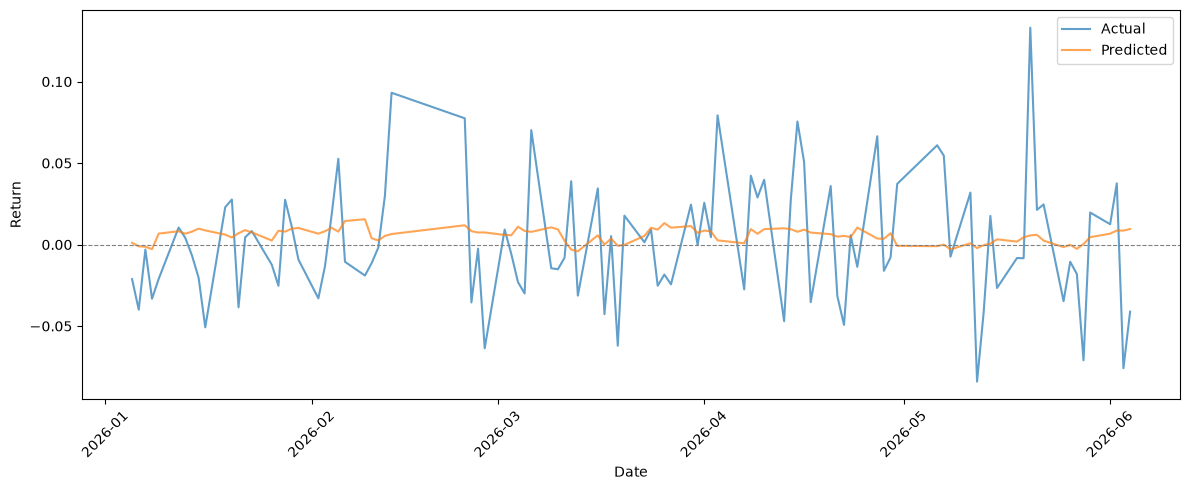

In [87]:
# Ridge fitted v.s. actual
plt.figure(figsize=(12, 5))
plt.plot(y_test.index.get_level_values('datetime'), y_test.values, label="Actual", alpha=0.7)
plt.plot(y_test.index.get_level_values('datetime'), test_preds, label="Predicted", alpha=0.7)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

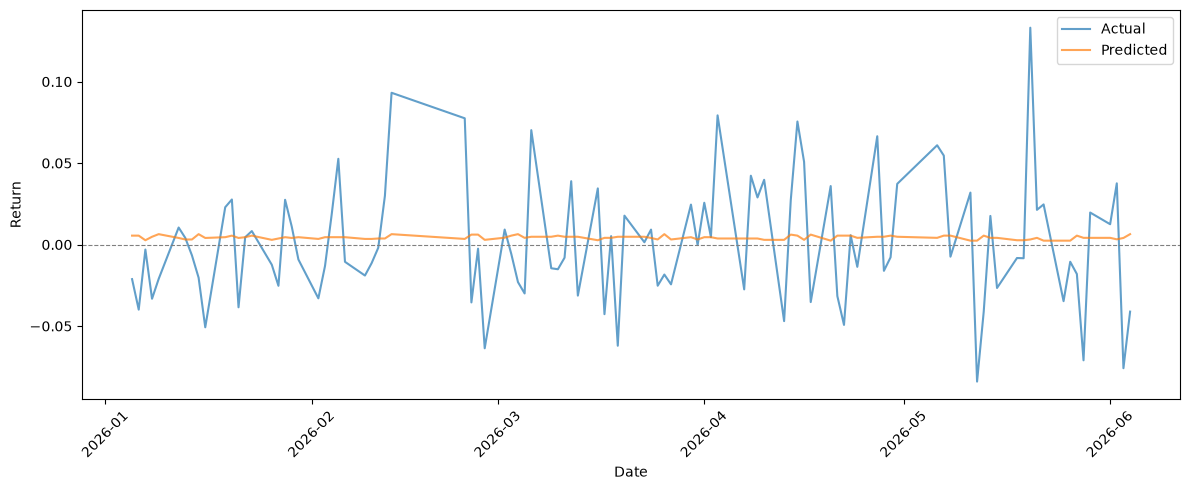

In [86]:
# LightGMB fitted v.s. actual
plt.figure(figsize=(12, 5))
plt.plot(y_test.index.get_level_values('datetime'), y_test.values, label="Actual", alpha=0.7)
plt.plot(y_test.index.get_level_values('datetime'), test_preds_lgb, label="Predicted", alpha=0.7)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

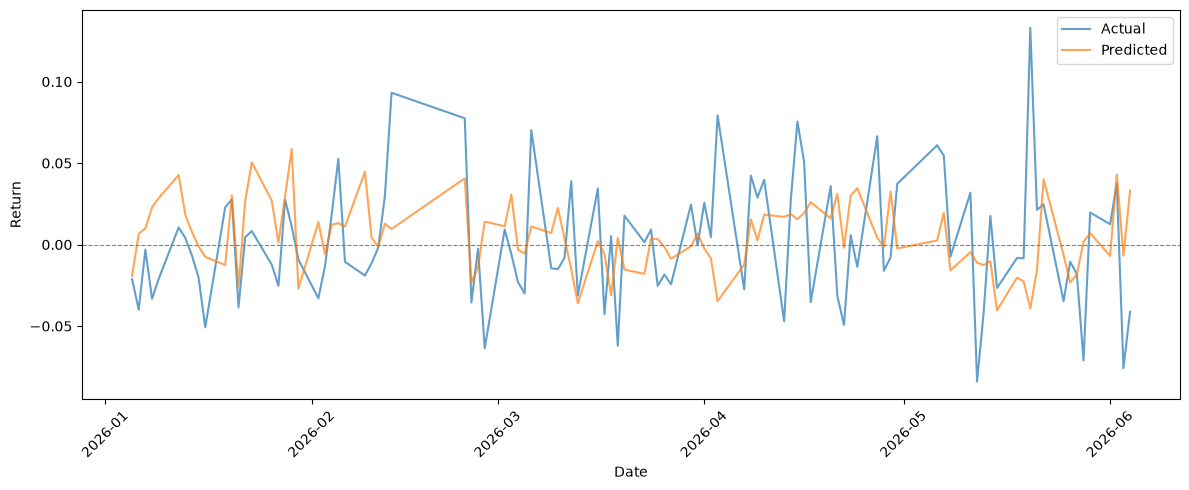

In [91]:
# MLP fitted v.s. actual
plt.figure(figsize=(12, 5))
plt.plot(y_test.index.get_level_values('datetime'), y_test.values, label="Actual", alpha=0.7)
plt.plot(y_test.index.get_level_values('datetime'), test_preds_mlp, label="Predicted", alpha=0.7)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

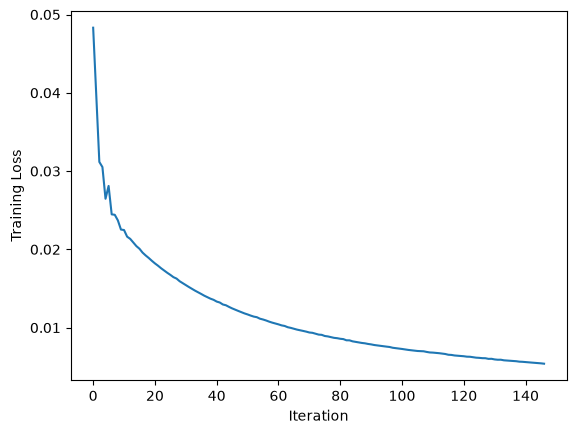

In [92]:
# MLP loss
####### this is just to see how the model has been functioning
plt.plot(mlp_model.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.show()